# Bandwidth-Aware Adaptive Chirp Mode Decomposition (BA-ACMD)

**BA-ACMD** (Chen *et al.*, 2024) guides ACMD with a **weighted spectrum trend (WST)**:

1. fit a smooth trend to the amplitude spectrum (over-complete Fourier basis);
2. partition bands at trend minima and weight them by spectral energy;
3. map each band’s normalized bandwidth to the ACMD penalty $\alpha_0$ via a
   power-law fit from Monte-Carlo filter-bank analysis;
4. extract modes **recursively**, strongest WST band first, and stop when the
   mode–signal correlation falls below a threshold `ce`.

This notebook reproduces the MATLAB demo `Example2.m` with `pysdkit.BA_ACMD`.

**Reference**

> S. Chen, L. Guo, J. Fan, C. Yi, K. Wang, W. Zhai.  
> *Bandwidth-aware adaptive chirp mode decomposition for railway bearing fault diagnosis.*  
> Structural Health Monitoring, 23(2):876–902, 2024.  
> DOI: [10.1177/14759217231174699](https://doi.org/10.1177/14759217231174699)

MATLAB code: [File Exchange 132792](https://www.mathworks.com/matlabcentral/fileexchange/132792).

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, hilbert

from pysdkit import BA_ACMD
from pysdkit._acmd.ba_acmd import (
    generate_demo_signal,
    gini_squared_envelope,
    extract_if_ia,
)

print(BA_ACMD(fs=5000))

Bandwidth-Aware Adaptive Chirp Mode Decomposition (BA-ACMD)


## 2. Algorithm outline

### 2.1 Spectrum trend & WST (`Spectrendgene`)

Let $S(f)$ be the one-sided amplitude spectrum. An over-complete Fourier model
(`coef_ovefour`) yields a smooth trend $T(f)$. Local minima of $T$ define band
edges. Inside band $b$,

$$
w_b = \frac{1}{|b|}\sum_{f\in b} S(f)^2,
\qquad
\mathrm{WST}(f)=w(f)\,T(f).
$$

Bands are ranked by $\max_{f\in b}\mathrm{WST}(f)$ (descending).

### 2.2 Bandwidth → $\alpha_0$

For normalized bandwidth $B_w=(f_u-f_\ell)/f_s$ (Ac = 0.3 map),

$$
\alpha_0 = \bigl(2.9868\,(B_w-0.002137)\bigr)^{3.9323}.
$$

### 2.3 Recursive ACMD

Initialize IF at the band mid-frequency, run BA-ACMD’s ACMD (IF update uses
$\overline{\Delta\mathrm{IF}}$), subtract the mode, and stop when
$\mathrm{corr}(\mathrm{mode}, x_0)<\texttt{ce}$.

## 3. MATLAB Example2 — synthetic mixture

Four components (wheelset impulses, random knocks, bearing outer-race impulses,
shaft harmonic) plus Gaussian noise (`SD = 0.2`), $f_s=5\,\mathrm{kHz}$.

N=5001, SNR=-0.62 dB


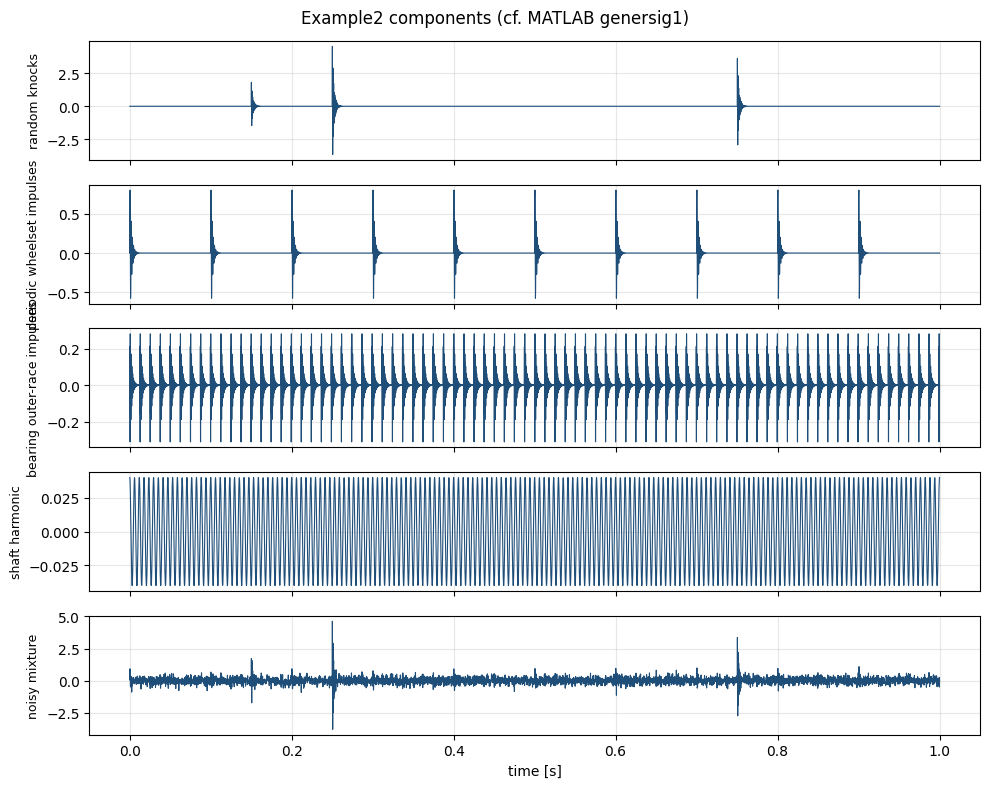

In [2]:
fs = 5000.0
t, Sign, snr_db, comps = generate_demo_signal(
    fs=fs, duration=1.0, noise_std=0.2, rng=np.random.default_rng(0)
)
Sig = comps["clean"]
print(f"N={Sign.size}, SNR={snr_db:.2f} dB")

fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
panels = [
    (comps["impulse_random"], "random knocks"),
    (comps["impulse_w"], "periodic wheelset impulses"),
    (comps["impulse_bear"], "bearing outer-race impulses"),
    (comps["harmonic"], "shaft harmonic"),
    (Sign, "noisy mixture"),
]
for ax, (y, title) in zip(axes, panels):
    ax.plot(t, y, color="#1f4e79", lw=0.8)
    ax.set_ylabel(title, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("time [s]")
plt.suptitle("Example2 components (cf. MATLAB genersig1)")
plt.tight_layout()
plt.show()

## 4. Weighted spectrum trend

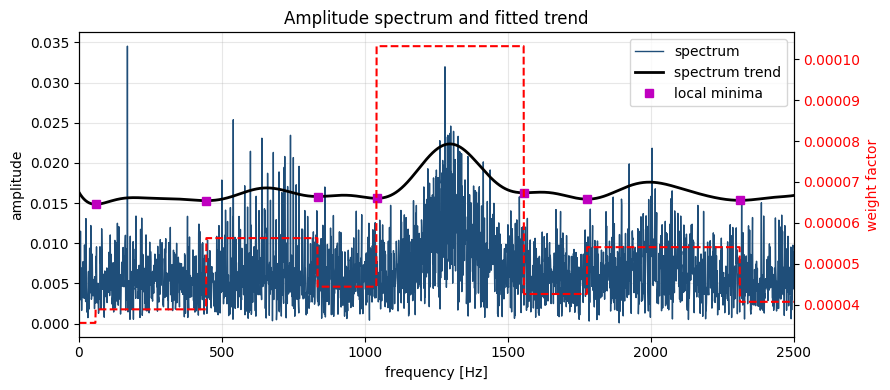

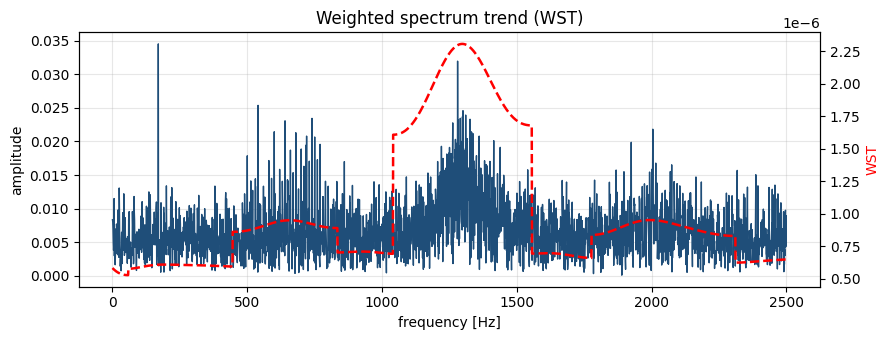

Ranked bands [f_lo, f_hi] (Hz):
[[1041.4 1555.6]
 [1777.7 2310.9]
 [ 446.2  834.3]
 [ 835.3 1040.4]
 [1556.6 1776.7]
 [2311.9 2499. ]]


In [3]:
offset = 0.01
cut_pfreq = 0.0015

ba = BA_ACMD(
    fs=fs,
    beta=1e-10,
    tol=1e-7,
    ce=0.15,  # slightly softer than MATLAB 0.3 to show more modes under RNG noise
    offset=offset,
    cut_pfreq=cut_pfreq,
    max_iter=80,
)

spec, weight, spec_trend, we_trend, sort_inter = ba.compute_spectrum_trend(Sign)
freq = np.linspace(0.0, fs / 2.0, spec.size)
minima, _ = find_peaks(-spec_trend)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(freq, spec, color="#1f4e79", lw=1.0, label="spectrum")
ax.plot(freq, spec_trend, color="k", lw=2.0, label="spectrum trend")
ax.plot(freq[minima], spec_trend[minima], "ms", label="local minima")
ax.set_xlim(0, fs / 2)
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("amplitude")
ax.legend(loc="upper right")
ax.set_title("Amplitude spectrum and fitted trend")
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(freq, weight, "r--", lw=1.5, label="weight")
ax2.set_ylabel("weight factor", color="r")
ax2.tick_params(axis="y", labelcolor="r")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(freq, spec, color="#1f4e79", lw=1.0, label="spectrum")
ax2 = ax.twinx()
ax2.plot(freq, we_trend, "r--", lw=1.8, label="weighted trend")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("amplitude")
ax2.set_ylabel("WST", color="r")
ax.set_title("Weighted spectrum trend (WST)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Ranked bands [f_lo, f_hi] (Hz):")
print(np.array_str(sort_inter[:6], precision=1))

## 5. BA-ACMD decomposition

modes: (8, 5001)
mean IF [Hz]: [2039.01929425 2431.7911658   673.39138015  978.90995269 1645.53309383
 2236.83345468  191.018227     23.28093588]
Gini (squared envelope): [0.5689421825947969, 0.5167009750022167, 0.6817716018291987, 0.5910120049059058, 0.6071764179167126, 0.5267366272736171, 0.5342681076103009, 0.5350684404198391]


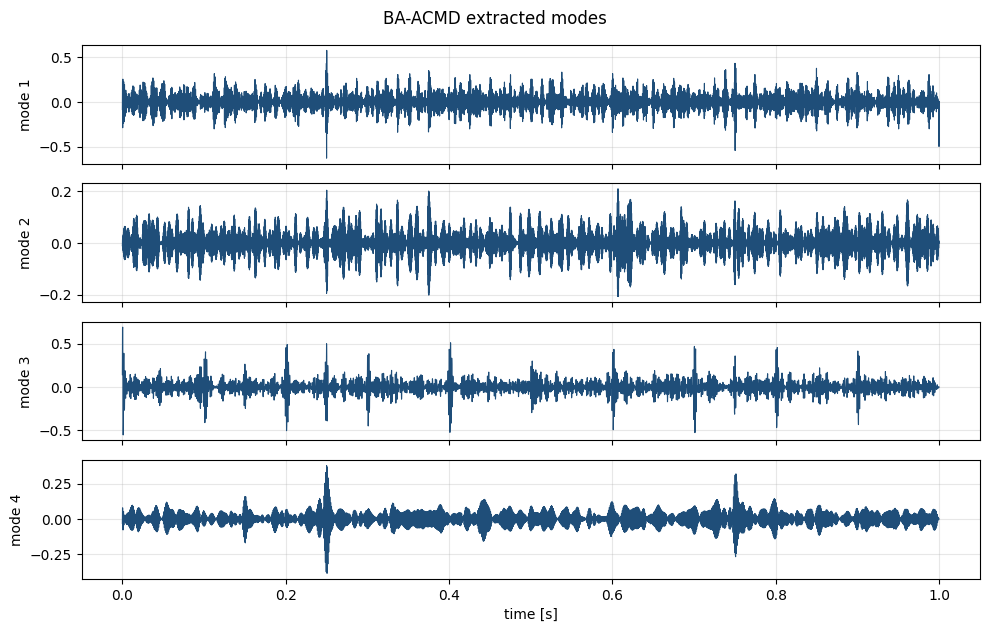

In [4]:
modes, ifs, ias = ba.fit_transform(Sign, return_all=True)
print("modes:", modes.shape)
print("mean IF [Hz]:", np.mean(ifs, axis=1))
print("Gini (squared envelope):", [gini_squared_envelope(m) for m in modes])

Kshow = min(4, modes.shape[0])
fig, axes = plt.subplots(Kshow, 1, figsize=(10, 1.6 * Kshow), sharex=True)
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(t, modes[k], color="#1f4e79", lw=0.8)
    ax.set_ylabel(f"mode {k+1}")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("time [s]")
plt.suptitle("BA-ACMD extracted modes")
plt.tight_layout()
plt.show()

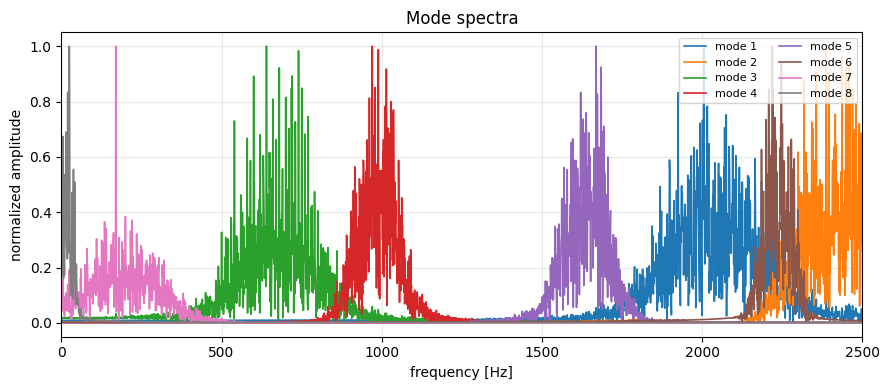

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for k in range(modes.shape[0]):
    Sp = 2 * np.abs(np.fft.fft(modes[k])) / modes[k].size
    Sp = Sp[: freq.size]
    ax.plot(freq, Sp / (Sp.max() + 1e-12), lw=1.2, label=f"mode {k+1}")
ax.set_xlim(0, fs / 2)
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("normalized amplitude")
ax.legend(loc="upper right", ncol=2, fontsize=8)
ax.set_title("Mode spectra")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Envelope spectrum of the most impulsive mode

Following Example2, inspect the Hilbert envelope spectrum of the mode with
largest Gini index (often the bearing-related band).

most impulsive mode index = 3, Gini = 0.682


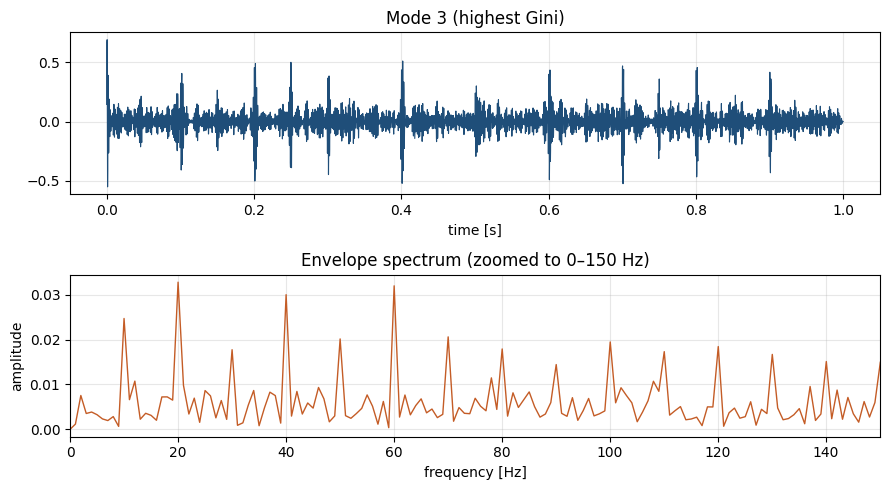

In [6]:
ginis = np.array([gini_squared_envelope(m) for m in modes])
k_star = int(np.argmax(ginis))
print(f"most impulsive mode index = {k_star+1}, Gini = {ginis[k_star]:.3f}")

_, ia = extract_if_ia(modes[k_star], fs)
env = ia - np.mean(ia)
Spe = 2 * np.abs(np.fft.fft(env)) / env.size
Spe = Spe[: freq.size]

fig, axes = plt.subplots(2, 1, figsize=(9, 5))
axes[0].plot(t, modes[k_star], color="#1f4e79", lw=0.8)
axes[0].set_title(f"Mode {k_star+1} (highest Gini)")
axes[0].set_xlabel("time [s]")
axes[0].grid(True, alpha=0.3)

axes[1].plot(freq, Spe, color="#c45c26", lw=1.0)
axes[1].set_xlim(0, 150)
axes[1].set_xlabel("frequency [Hz]")
axes[1].set_ylabel("amplitude")
axes[1].set_title("Envelope spectrum (zoomed to 0–150 Hz)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. API summary

```python
from pysdkit import BA_ACMD
from pysdkit._acmd.ba_acmd import generate_demo_signal

t, x, snr, comps = generate_demo_signal(fs=5000, noise_std=0.2)
ba = BA_ACMD(fs=5000, beta=1e-10, tol=1e-7, ce=0.3,
             offset=0.01, cut_pfreq=0.0015)
modes = ba.fit_transform(x)                 # (K, N)
modes, IFs, IAs = ba.fit_transform(x, return_all=True)
```

| Parameter | Role | Example2 |
| --- | --- | --- |
| `fs` | sampling rate | `5000` |
| `beta` | IF smoothing | `1e-10` |
| `tol` | ACMD tolerance | `1e-7` |
| `ce` | correlation stop | `0.3` |
| `offset` / `cut_pfreq` | WST fitting | `0.01` / `0.0015` |